In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer

In [2]:

df = load_breast_cancer()  
x = df.data
y = df.target
feature_name = df.feature_names

df_data = pd.DataFrame(
    df.data,
    columns = df.feature_names
)

df_data['target'] = y
df_data.info()
df_data.head()





<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         569 non-null

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


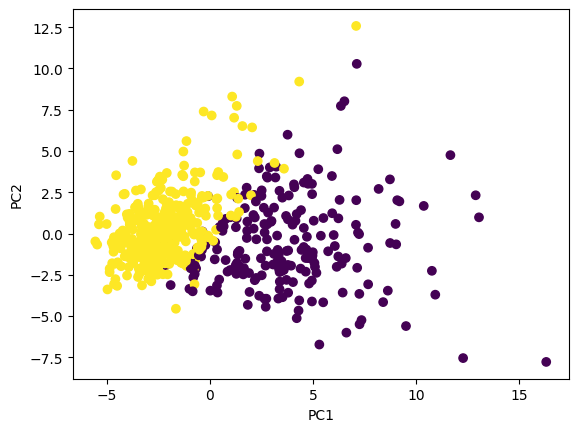

In [3]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.decomposition import PCA

#Hiện tại đang dùng pca để giảm chiều dữ liệu nhằm mục đích nhưn kính viễn vọng xem class phân bố

X_scaled = StandardScaler().fit_transform(x)
pca = PCA(n_components = 2)

X_pca = pca.fit_transform(X_scaled)

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=y
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()


In [4]:
print(df_data['target'].value_counts())
#1 Nạp dữ liệu thành công và xác nhận 0 = ác tính và có 212 ác tính và 357 lành tính


target
1    357
0    212
Name: count, dtype: int64


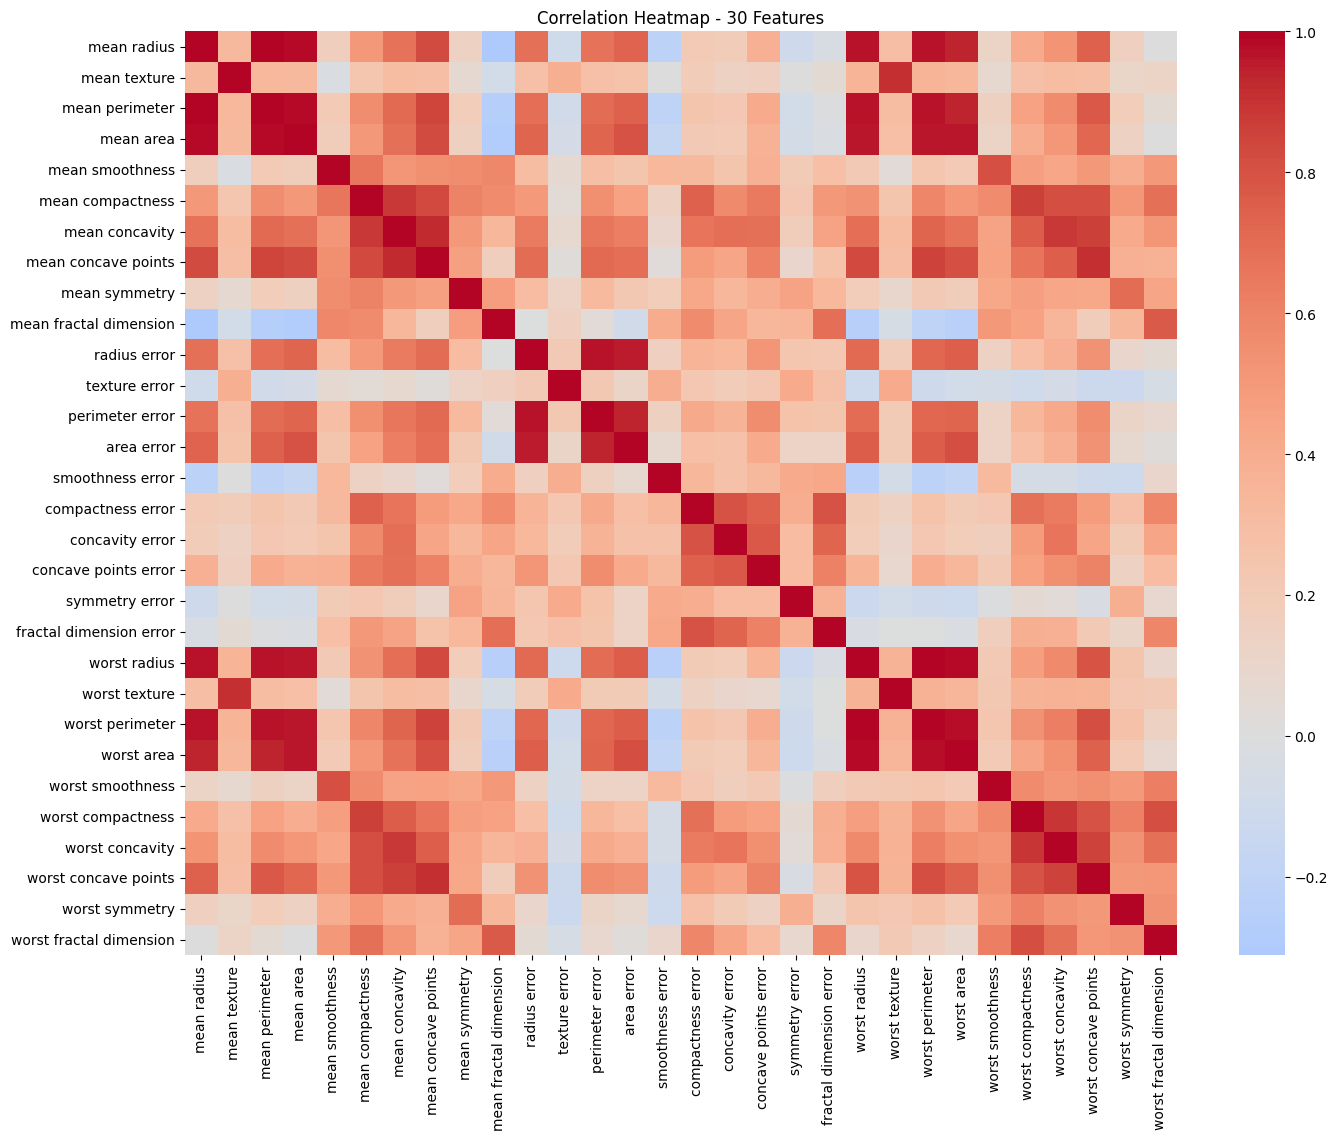

In [5]:
import seaborn as sns
corr = df_data.drop(columns='target').corr()

plt.figure(figsize=(16, 12))

sns.heatmap(
    corr,
    cmap='coolwarm',
    center=0
)

plt.title('Correlation Heatmap - 30 Features')
plt.show()

In [6]:
corr = df_data.drop(columns='target').corr()

# Chỉ lấy nửa trên của ma trận để không bị lặp
upper = corr.where(
    np.triu(np.ones(corr.shape), k=1).astype(bool)
)

high_corr = (
    upper
    .stack()
    .sort_values(ascending=False)
)

high_corr[high_corr.abs() >= 0.8]

mean radius          mean perimeter             0.997855
worst radius         worst perimeter            0.993708
mean radius          mean area                  0.987357
mean perimeter       mean area                  0.986507
worst radius         worst area                 0.984015
worst perimeter      worst area                 0.977578
radius error         perimeter error            0.972794
mean perimeter       worst perimeter            0.970387
mean radius          worst radius               0.969539
mean perimeter       worst radius               0.969476
mean radius          worst perimeter            0.965137
mean area            worst radius               0.962746
                     worst area                 0.959213
                     worst perimeter            0.959120
radius error         area error                 0.951830
mean perimeter       worst area                 0.941550
mean radius          worst area                 0.941082
perimeter error      area error

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [8]:
from sklearn.svm import SVC

svm_no_scale = SVC(
    kernel='rbf'
)

svm_no_scale.fit(
    X_train,
    y_train
)

y_pred_no_scale = svm_no_scale.predict(X_test)

In [9]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

print(
    "Accuracy:",
    accuracy_score(y_test, y_pred_no_scale)
)

print(
    classification_report(
        y_test,
        y_pred_no_scale,
        target_names=['malignant', 'benign']
    )
)

Accuracy: 0.9298245614035088
              precision    recall  f1-score   support

   malignant       0.95      0.86      0.90        42
      benign       0.92      0.97      0.95        72

    accuracy                           0.93       114
   macro avg       0.93      0.91      0.92       114
weighted avg       0.93      0.93      0.93       114



In [10]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

svm_scaled = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='rbf'))
])

svm_scaled.fit(
    X_train,
    y_train
)

y_pred_scaled = svm_scaled.predict(X_test)

print(
    "Accuracy:",
    accuracy_score(y_test, y_pred_scaled)
)

print(
    classification_report(
        y_test,
        y_pred_scaled,
        target_names=['malignant', 'benign']
    )
)

Accuracy: 0.9824561403508771
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [11]:
from sklearn.metrics import accuracy_score, recall_score

result = pd.DataFrame({
    'Model': [
        'SVM - No Scale',
        'SVM - StandardScaler'
    ],
    'Accuracy': [
        accuracy_score(y_test, y_pred_no_scale),
        accuracy_score(y_test, y_pred_scaled)
    ],
    'Recall Malignant': [
        recall_score(y_test, y_pred_no_scale, pos_label=0),
        recall_score(y_test, y_pred_scaled, pos_label=0)
    ]
})

result

,Model,Accuracy,Recall Malignant
0,SVM - No Scale,0.929825,0.857143
1,SVM - StandardScaler,0.982456,0.976190


In [12]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, recall_score

kernels = ['linear', 'rbf', 'poly']

results = []

for kernel in kernels:

    model = Pipeline([
        ('scaler', StandardScaler()),
        ('svm', SVC(
            kernel=kernel,
            C=1
        ))
    ])

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    results.append({
        'Kernel': kernel,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Recall Malignant': recall_score(
            y_test,
            y_pred,
            pos_label=0
        )
    })

results_df = pd.DataFrame(results)

results_df

,Kernel,Accuracy,Recall Malignant
0,linear,0.973684,0.976190
1,rbf,0.982456,0.976190
2,poly,0.912281,0.761905


In [13]:
from sklearn.metrics import make_scorer, recall_score

malignant_recall = make_scorer(
    recall_score,
    pos_label=0
)

from sklearn.model_selection import GridSearchCV

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC())
])

param_grid = {
    'svm__kernel': ['linear', 'rbf', 'poly'],
    'svm__C': [0.1, 1, 10, 100],
    'svm__gamma': ['scale', 0.01, 0.1, 1]
}

In [14]:
grid = GridSearchCV(
    pipeline,
    param_grid,
    scoring=malignant_recall,
    cv=5,
    n_jobs=-1
)

grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...svm', SVC())])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'svm__C': [0.1, 1, ...], 'svm__gamma': ['scale', 0.01, ...], 'svm__kernel': ['linear', 'rbf', ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","make_scorer(r..., pos_label=0)"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and pa

In [15]:
print("Best params:")
print(grid.best_params_)

print("\nBest CV Recall malignant:")
print(grid.best_score_)

Best params:
{'svm__C': 1, 'svm__gamma': 'scale', 'svm__kernel': 'rbf'}

Best CV Recall malignant:
0.9588235294117646


In [16]:
best_model = grid.best_estimator_

y_pred_best = best_model.predict(X_test)

print(
    "Recall malignant:",
    recall_score(
        y_test,
        y_pred_best,
        pos_label=0
    )
)

print(
    "Accuracy:",
    accuracy_score(
        y_test,
        y_pred_best
    )
)

Recall malignant: 0.9761904761904762
Accuracy: 0.9824561403508771


In [17]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred_best,
        target_names=['malignant', 'benign']
    )
)

              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [18]:
cv_results = pd.DataFrame(grid.cv_results_)

cv_results[
    [
        'param_svm__kernel',
        'param_svm__C',
        'param_svm__gamma',
        'mean_test_score'
    ]
].head()

,param_svm__kernel,param_svm__C,param_svm__gamma,mean_test_score
0,linear,0.1,scale,0.952941
1,rbf,0.1,scale,0.894118
2,poly,0.1,scale,0.552941
3,linear,0.1,0.01,0.952941
4,rbf,0.1,0.01,0.870588


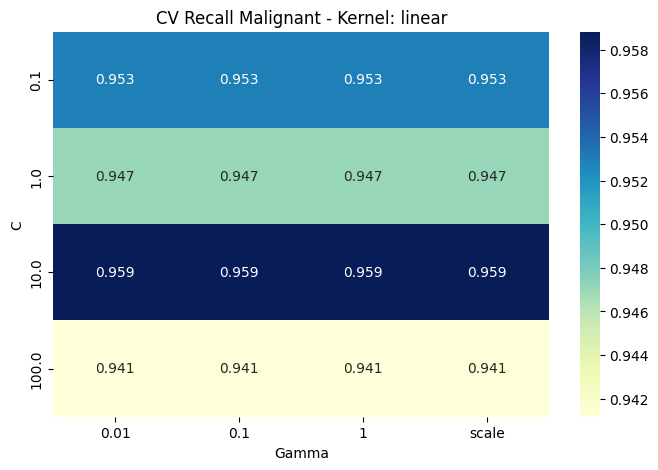

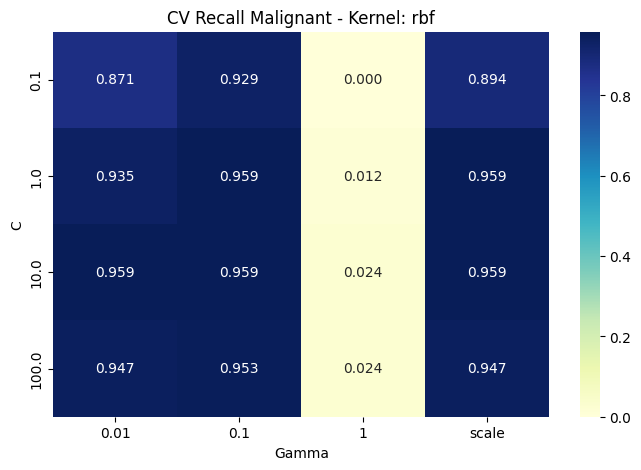

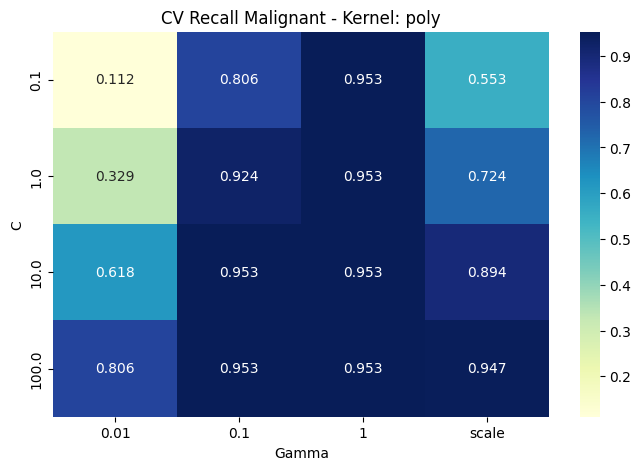

In [19]:
kernels = ['linear', 'rbf', 'poly']

for kernel in kernels:

    data = cv_results[
        cv_results['param_svm__kernel'] == kernel
    ]

    pivot = data.pivot_table(
        index='param_svm__C',
        columns='param_svm__gamma',
        values='mean_test_score'
    )

    plt.figure(figsize=(8, 5))

    sns.heatmap(
        pivot,
        annot=True,
        fmt='.3f',
        cmap='YlGnBu'
    )

    plt.title(
        f'CV Recall Malignant - Kernel: {kernel}'
    )

    plt.xlabel('Gamma')
    plt.ylabel('C')

    plt.show()

In [20]:
y_pred = best_model.predict(X_test)
from sklearn.metrics import (
    accuracy_score,
    recall_score,
    precision_score,
    f1_score,
    classification_report
)

print("Accuracy:", accuracy_score(y_test, y_pred))

print(
    "Recall malignant:",
    recall_score(
        y_test,
        y_pred,
        pos_label=0
    )
)

print(
    "Precision malignant:",
    precision_score(
        y_test,
        y_pred,
        pos_label=0
    )
)

print(
    "F1 malignant:",
    f1_score(
        y_test,
        y_pred,
        pos_label=0
    )
)

Accuracy: 0.9824561403508771
Recall malignant: 0.9761904761904762
Precision malignant: 0.9761904761904762
F1 malignant: 0.9761904761904762


In [21]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=['malignant', 'benign']
    )
)

              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



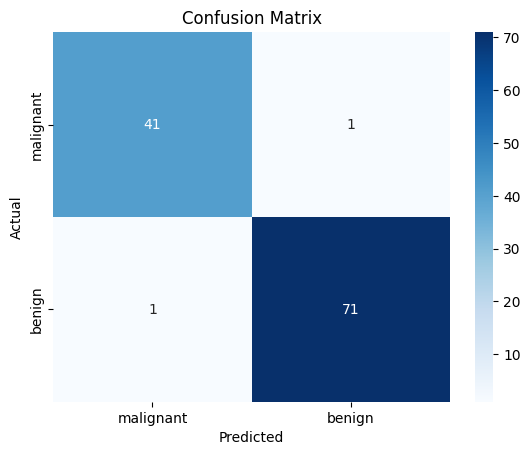

In [22]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['malignant', 'benign'],
    yticklabels=['malignant', 'benign']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [23]:
svm = best_model.named_steps['svm']

print(svm.n_support_)

total_sv = svm.n_support_.sum()

print("Total support vectors:", total_sv)

percentage = total_sv / len(X_train) * 100

print(f"Support vectors: {percentage:.2f}% of training data")

[51 46]
Total support vectors: 97
Support vectors: 21.32% of training data


In [24]:
scores = best_model.decision_function(X_test)
malignant_score = -scores
from sklearn.metrics import recall_score, precision_score

thresholds = np.linspace(
    malignant_score.min(),
    malignant_score.max(),
    1000
)

results = []

for threshold in thresholds:

    y_pred_threshold = (
        malignant_score >= threshold
    ).astype(int)

    # malignant = 0
    y_pred_threshold = 1 - y_pred_threshold

    recall = recall_score(
        y_test,
        y_pred_threshold,
        pos_label=0
    )

    precision = precision_score(
        y_test,
        y_pred_threshold,
        pos_label=0,
        zero_division=0
    )

    results.append({
        'threshold': threshold,
        'recall': recall,
        'precision': precision
    })

threshold_df = pd.DataFrame(results)

valid = threshold_df[
    threshold_df['recall'] >= 0.98
]

best_threshold = valid.loc[
    valid['precision'].idxmax()
]

print(best_threshold)

threshold   -0.762641
recall       1.000000
precision    0.763636
Name: 334, dtype: float64


In [25]:
threshold = best_threshold['threshold']

y_pred_threshold = (
    malignant_score >= threshold
).astype(int)

# 1 ở trên nghĩa là malignant
# chuyển về label gốc: malignant = 0, benign = 1
y_pred_threshold = 1 - y_pred_threshold

In [26]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_pred_threshold
)

print(cm)

[[42  0]
 [13 59]]


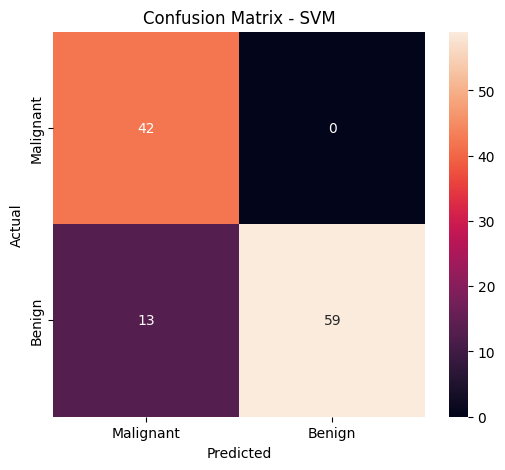

In [27]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=['Malignant', 'Benign'],
    yticklabels=['Malignant', 'Benign']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - SVM')

plt.show()

In [28]:
fn = cm[0, 1]

print("Số ca malignant bị bỏ sót:", fn)

Số ca malignant bị bỏ sót: 0


In [29]:
from sklearn.linear_model import LogisticRegression

logistic = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(
        max_iter=5000
    ))
])

logistic.fit(X_train, y_train)

y_pred_lr = logistic.predict(X_test)

In [30]:
from sklearn.metrics import (
    accuracy_score,
    recall_score,
    precision_score,
    f1_score
)

print("Logistic Regression")

print(
    "Accuracy:",
    accuracy_score(y_test, y_pred_lr)
)

print(
    "Recall malignant:",
    recall_score(
        y_test,
        y_pred_lr,
        pos_label=0
    )
)

print(
    "Precision malignant:",
    precision_score(
        y_test,
        y_pred_lr,
        pos_label=0
    )
)

print(
    "F1 malignant:",
    f1_score(
        y_test,
        y_pred_lr,
        pos_label=0
    )
)

Logistic Regression
Accuracy: 0.9824561403508771
Recall malignant: 0.9761904761904762
Precision malignant: 0.9761904761904762
F1 malignant: 0.9761904761904762


## 12. So sánh với Logistic Regression (TT-04)

**Kết quả ở threshold mặc định (0.5):** SVM (RBF, đã tune) và Logistic Regression cho **kết quả giống hệt nhau** — cùng confusion matrix, cùng accuracy 98.25%, recall malignant 97.62%. Với breast cancer dataset (sau khi chuẩn hóa `StandardScaler`), 2 lớp gần như tách tuyến tính được, nên kernel phi tuyến của SVM không tạo được lợi thế rõ rệt so với 1 mặt phẳng tuyến tính của Logistic Regression.

**Khi tune threshold để đạt recall malignant = 1.0 (không bỏ sót ca ác tính nào — mục tiêu quan trọng nhất trong y tế):**
- SVM đạt precision cao hơn một chút so với LR ở cùng mức recall = 1.0 → SVM tạo ít false positive hơn khi ép recall lên tối đa.
- Điều này cho thấy đường biên quyết định phi tuyến của SVM linh hoạt hơn một chút ở vùng biên (margin) giữa 2 lớp.

**Về độ phức tạp & khả năng diễn giải:**
- Logistic Regression: mỗi feature có đúng 1 hệ số (30 hệ số), dễ diễn giải (hệ số dương/âm, độ lớn), train nhanh, không cần GridSearch nhiều tham số.
- SVM (RBF): cần tune 3 siêu tham số (C, gamma, kernel), dùng ~21% dữ liệu train làm support vectors, là "hộp đen" — không diễn giải trực tiếp được như hệ số hồi quy.

**Kết luận — cái nào tốt hơn ở đây?**
Về performance thuần túy: **gần như ngang nhau**, SVM nhỉnh hơn một chút (precision cao hơn tại điểm recall=1.0). Nhưng chênh lệch quá nhỏ để coi là có ý nghĩa thống kê trên tập test chỉ 114 mẫu.

Nếu ưu tiên **hiệu năng tối đa + chấp nhận hộp đen** → chọn SVM (RBF, tuned).
Nếu ưu tiên **tốc độ train, khả năng diễn giải cho bác sĩ/stakeholder, và mô hình đơn giản dễ bảo trì** → chọn Logistic Regression, vì performance gần như tương đương mà chi phí (thời gian tune, độ phức tạp) thấp hơn nhiều.

→ Trong ngữ cảnh y tế cần giải thích quyết định, **Logistic Regression là lựa chọn thực tế hơn** dù SVM nhỉnh hơn 1 chút về mặt số liệu.

In [31]:
from sklearn.metrics import confusion_matrix

# Luu y: bien 'cm' o cell truoc da bi ghi de boi buoc threshold-tuning (cell 25),
# nen tinh lai confusion matrix SVM o threshold mac dinh (0.5) tu y_pred cho chinh xac
cm_svm_default = confusion_matrix(y_test, y_pred)
cm_lr = confusion_matrix(y_test, y_pred_lr)

print("Confusion Matrix - Logistic Regression (threshold mac dinh)")
print(cm_lr)

print("\nConfusion Matrix - SVM best_model (threshold mac dinh)")
print(cm_svm_default)


Confusion Matrix - Logistic Regression (threshold mac dinh)
[[41  1]
 [ 1 71]]

Confusion Matrix - SVM best_model (threshold mac dinh)
[[41  1]
 [ 1 71]]


In [32]:
# Threshold tuning cho Logistic Regression (giống cách đã làm với SVM)
# de xem LR co the dat recall malignant = 1.0 (khong bo sot ca ac tinh) hay khong

scores_lr = logistic.decision_function(X_test)
malignant_score_lr = -scores_lr

thresholds_lr = np.linspace(
    malignant_score_lr.min(),
    malignant_score_lr.max(),
    1000
)

results_lr = []

for threshold in thresholds_lr:
    y_pred_t = (malignant_score_lr >= threshold).astype(int)
    y_pred_t = 1 - y_pred_t

    recall = recall_score(y_test, y_pred_t, pos_label=0)
    precision = precision_score(y_test, y_pred_t, pos_label=0, zero_division=0)

    results_lr.append({
        'threshold': threshold,
        'recall': recall,
        'precision': precision
    })

threshold_df_lr = pd.DataFrame(results_lr)

valid_lr = threshold_df_lr[threshold_df_lr['recall'] >= 1.0]
best_threshold_lr = valid_lr.loc[valid_lr['precision'].idxmax()]

print("SVM  - threshold tot nhat khi recall malignant = 1.0:")
print(f"  precision = {best_threshold['precision']:.4f}, recall = {best_threshold['recall']:.4f}")

print("\nLR   - threshold tot nhat khi recall malignant = 1.0:")
print(f"  precision = {best_threshold_lr['precision']:.4f}, recall = {best_threshold_lr['recall']:.4f}")

SVM  - threshold tot nhat khi recall malignant = 1.0:
  precision = 0.7636, recall = 1.0000

LR   - threshold tot nhat khi recall malignant = 1.0:
  precision = 0.7500, recall = 1.0000


In [33]:
compare = pd.DataFrame({
    'Model': ['SVM (RBF, tuned)', 'Logistic Regression'],
    'Accuracy (default thr)': [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_pred_lr)
    ],
    'Recall Malignant (default thr)': [
        recall_score(y_test, y_pred, pos_label=0),
        recall_score(y_test, y_pred_lr, pos_label=0)
    ],
    'Precision @ Recall=1.0': [
        best_threshold['precision'],
        best_threshold_lr['precision']
    ],
    'So tham so / do phuc tap': [
        f"{total_sv} support vectors ({percentage:.1f}% du lieu train)",
        f"{X_train.shape[1]} trong so (1 he so / feature)"
    ]
})

compare

,Model,Accuracy (default thr),Recall Malignant (default thr),Precision @ Recall=1.0,So tham so / do phuc tap
0,"SVM (RBF, tuned)",0.982456,0.97619,0.763636,97 support vectors (21.3% du lieu train)
1,Logistic Regression,0.982456,0.97619,0.750000,30 trong so (1 he so / feature)
